# Exploratory Data Analysis: Togo - Dapaong

This notebook contains comprehensive exploratory data analysis for the Togo solar farm dataset.

## Objectives
1. Summary Statistics & Missing-Value Report
2. Outlier Detection & Basic Cleaning
3. Time Series Analysis
4. Cleaning Impact Analysis
5. Correlation & Relationship Analysis
6. Wind & Distribution Analysis
7. Temperature Analysis
8. Bubble Chart Visualization


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the data
df = pd.read_csv('../data/togo-dapaong_qc.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Dataset shape: (525600, 19)
Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


## 1. Summary Statistics & Missing-Value Report


In [2]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("=" * 80)
print("SUMMARY STATISTICS FOR NUMERIC COLUMNS")
print("=" * 80)
print(df[numeric_cols].describe())


SUMMARY STATISTICS FOR NUMERIC COLUMNS
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       0.0000

In [3]:
# Missing value analysis
print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)
missing_data = df.isna().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

# Identify columns with >5% nulls
high_missing = missing_df[missing_df['Percentage'] > 5]
if len(high_missing) > 0:
    print(f"\nColumns with >5% missing values:")
    print(high_missing)
else:
    print("\nNo columns have more than 5% missing values.")


MISSING VALUE ANALYSIS
          Missing Count  Percentage
Comments         525600       100.0

Columns with >5% missing values:
          Missing Count  Percentage
Comments         525600       100.0


## 2. Outlier Detection & Basic Cleaning

### 2.1 Outlier Detection using Z-scores


In [4]:
# Key columns for outlier detection
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Calculate Z-scores
z_scores = {}
outlier_flags = pd.DataFrame(index=df.index)

for col in outlier_cols:
    if col in df.columns:
        z_scores[col] = np.abs(stats.zscore(df[col].dropna()))
        outlier_flags[col] = z_scores[col] > 3
        print(f"{col}: {outlier_flags[col].sum()} outliers (|Z| > 3)")

# Combine outlier flags
outlier_flags['Any_Outlier'] = outlier_flags.any(axis=1)
print(f"\nTotal rows with at least one outlier: {outlier_flags['Any_Outlier'].sum()}")
print(f"Percentage of rows with outliers: {(outlier_flags['Any_Outlier'].sum() / len(df)) * 100:.2f}%")


GHI: 305 outliers (|Z| > 3)
DNI: 1062 outliers (|Z| > 3)
DHI: 3415 outliers (|Z| > 3)
ModA: 137 outliers (|Z| > 3)
ModB: 206 outliers (|Z| > 3)
WS: 3510 outliers (|Z| > 3)
WSgust: 3915 outliers (|Z| > 3)

Total rows with at least one outlier: 9251
Percentage of rows with outliers: 1.76%


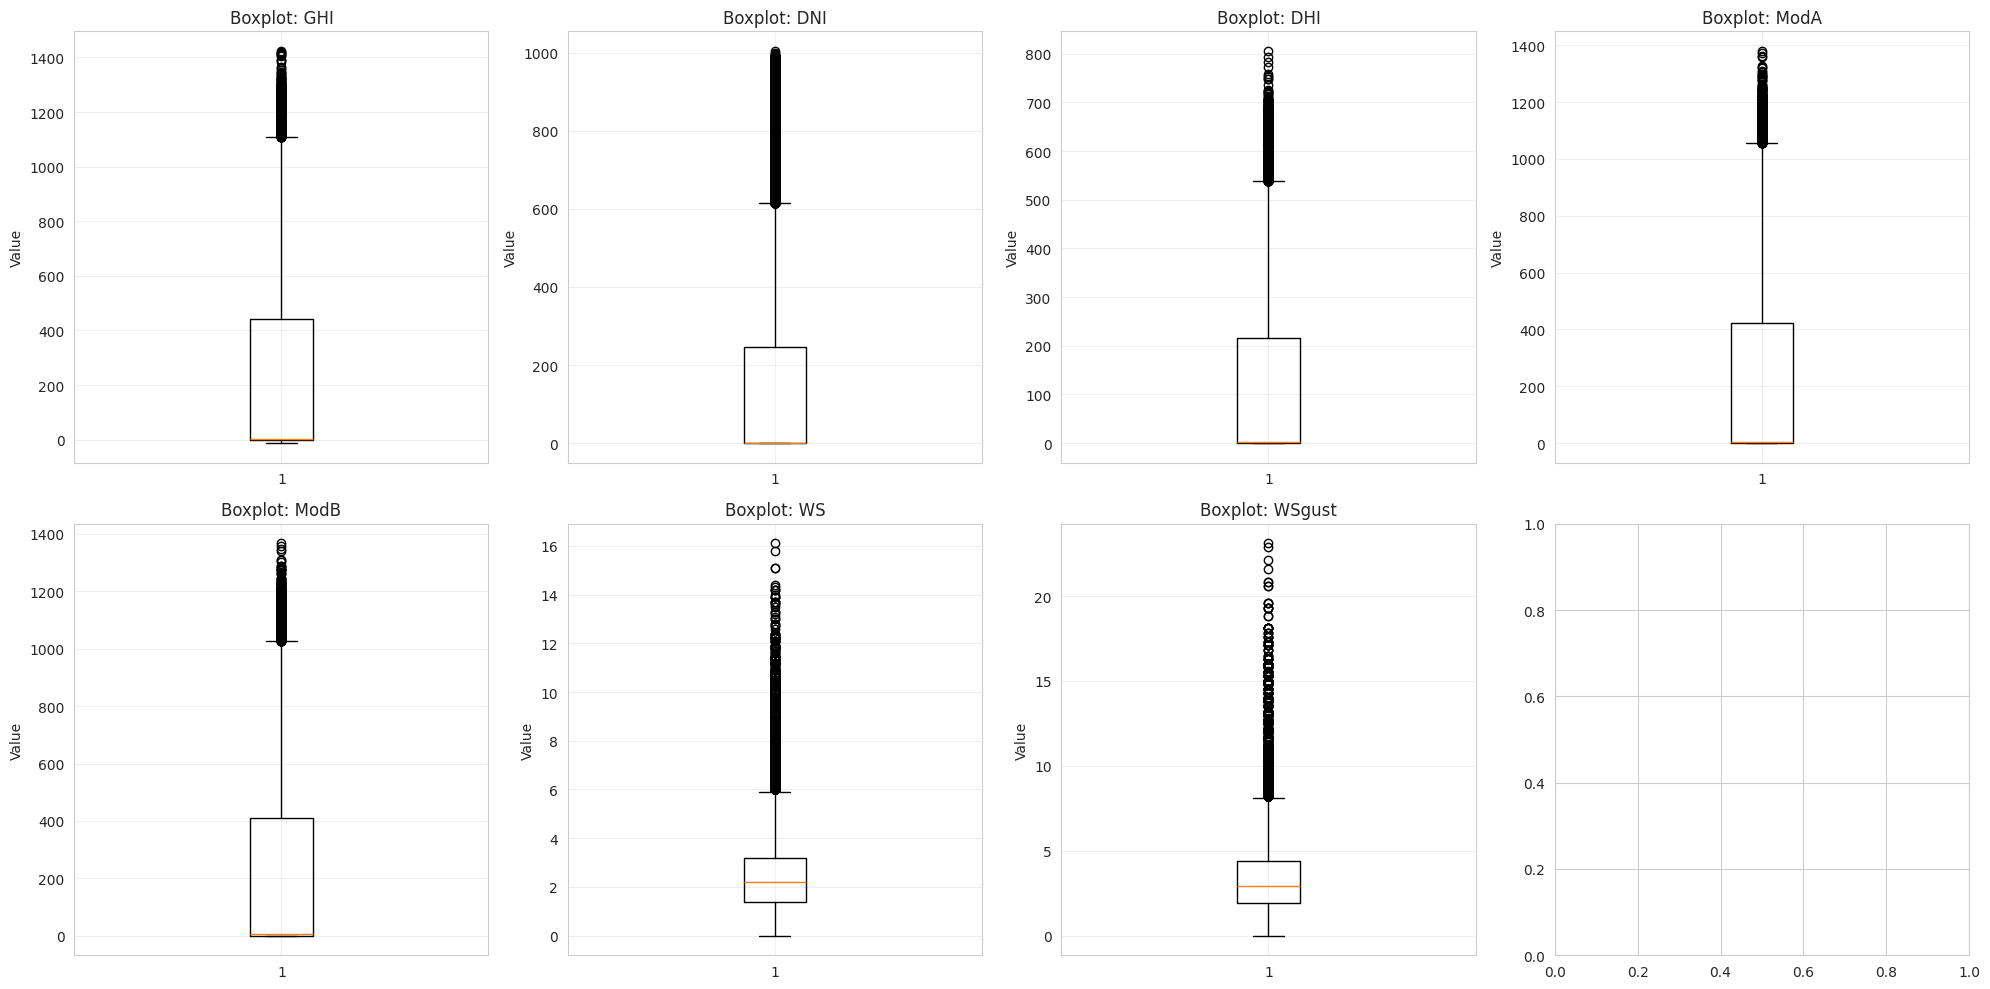

In [5]:
# Visualize outliers for key columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(outlier_cols[:7]):
    if col in df.columns:
        # Box plot
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Boxplot: {col}')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.2 Data Cleaning


In [6]:
# Create a copy for cleaning
df_clean = df.copy()

# Handle negative values in solar irradiance (should be >= 0)
solar_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']
for col in solar_cols:
    if col in df_clean.columns:
        negative_count = (df_clean[col] < 0).sum()
        if negative_count > 0:
            print(f"{col}: {negative_count} negative values found. Replacing with 0.")
            df_clean[col] = df_clean[col].clip(lower=0)

# Handle missing values in key columns using median imputation
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS']
for col in key_cols:
    if col in df_clean.columns:
        missing_count = df_clean[col].isna().sum()
        if missing_count > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"{col}: Filled {missing_count} missing values with median ({median_val:.2f})")

# Handle outliers - cap extreme values instead of removing (to preserve time series continuity)
for col in outlier_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        if outliers_count > 0:
            df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
            print(f"{col}: Capped {outliers_count} outliers using IQR method")

print("\nCleaning completed!")


GHI: 257385 negative values found. Replacing with 0.
DNI: Capped 22 outliers using IQR method
WS: Capped 635 outliers using IQR method
WSgust: Capped 635 outliers using IQR method

Cleaning completed!


## 3. Time Series Analysis


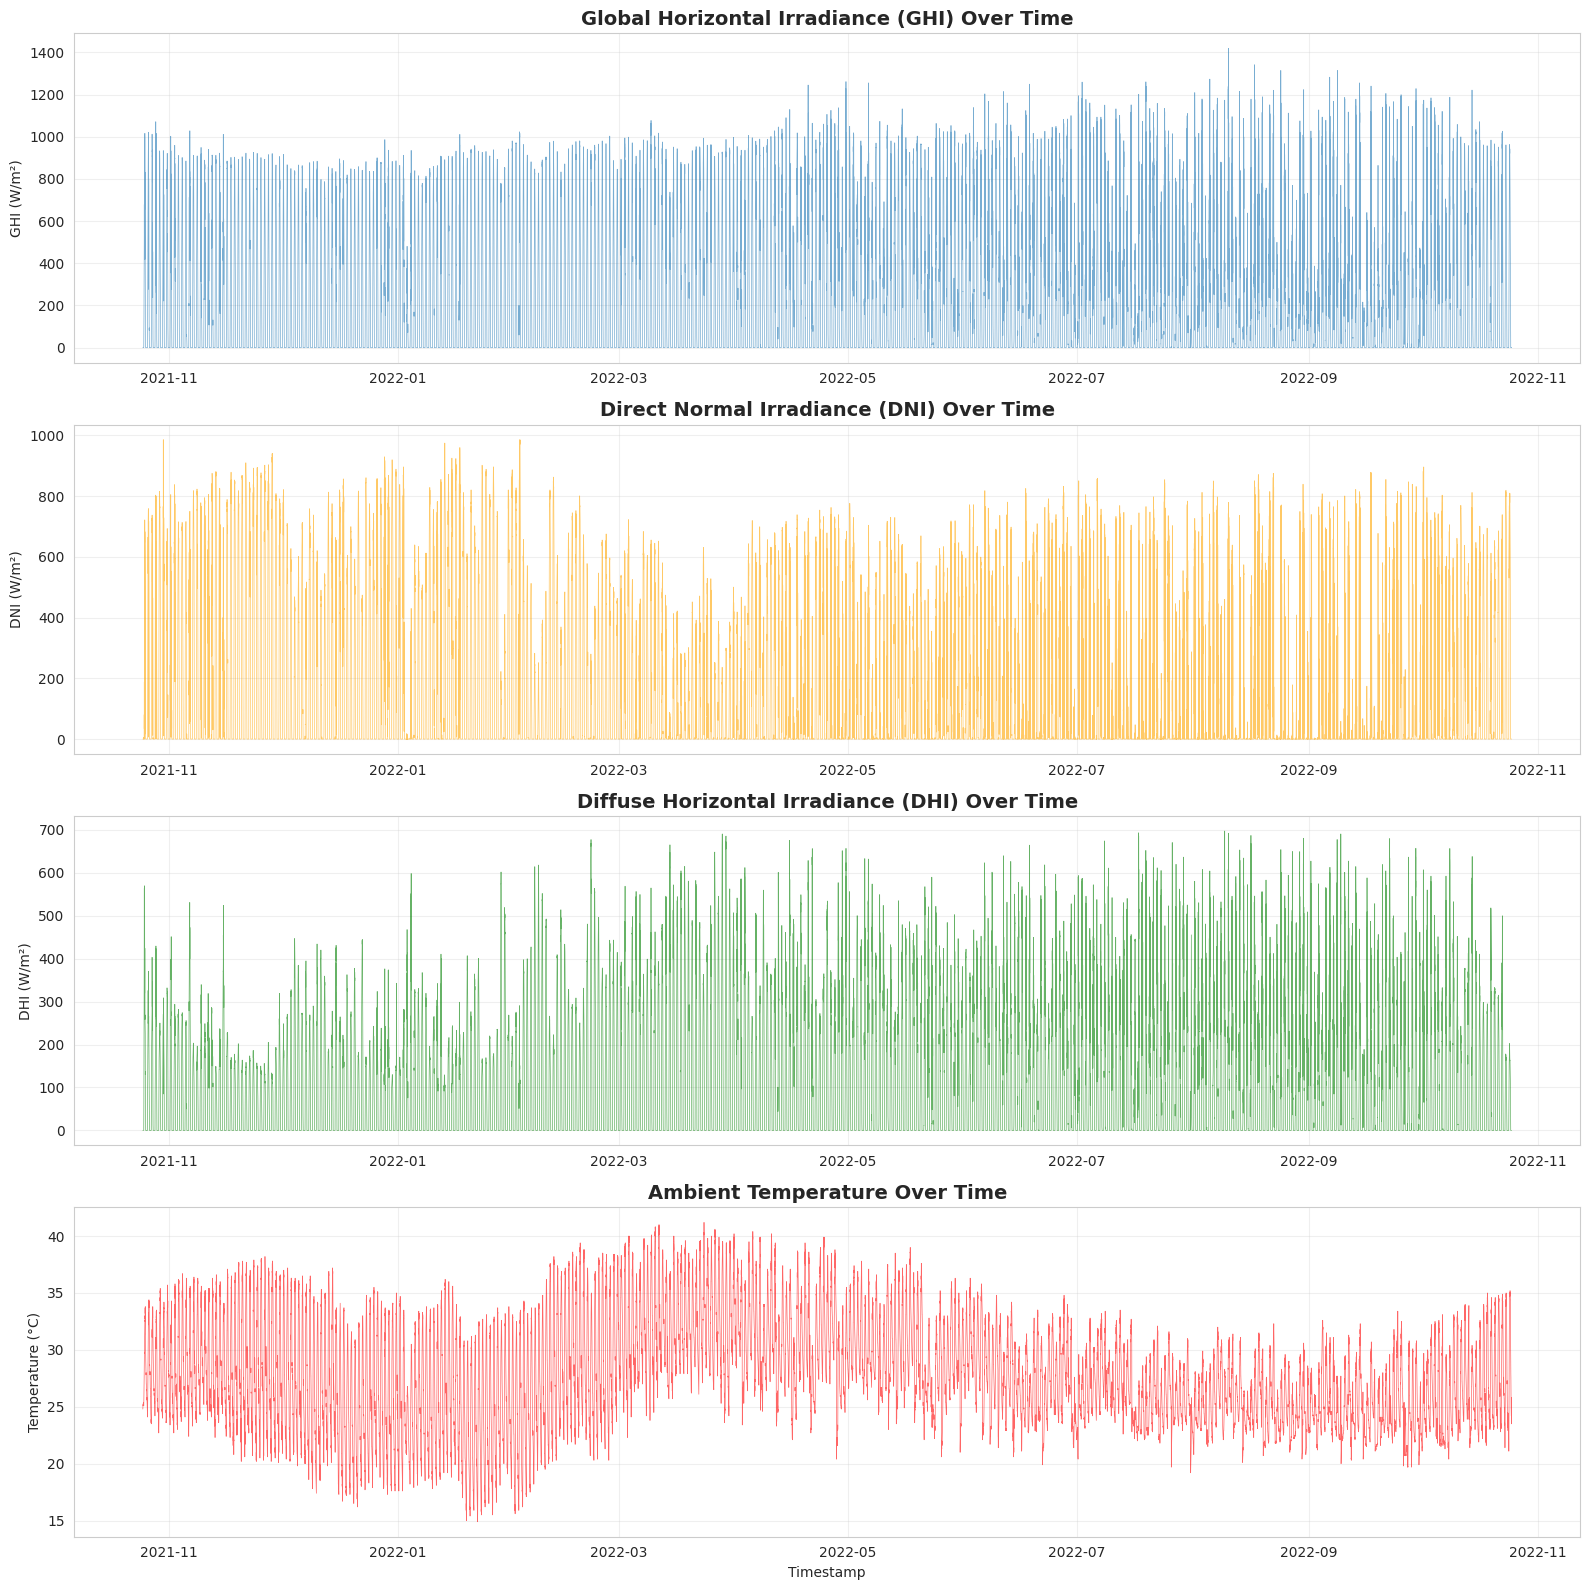

In [7]:
# Set Timestamp as index for time series analysis
df_clean_ts = df_clean.set_index('Timestamp')

# Extract time features
df_clean['Year'] = df_clean['Timestamp'].dt.year
df_clean['Month'] = df_clean['Timestamp'].dt.month
df_clean['Day'] = df_clean['Timestamp'].dt.day
df_clean['Hour'] = df_clean['Timestamp'].dt.hour
df_clean['DayOfWeek'] = df_clean['Timestamp'].dt.dayofweek

# Time series plots for key variables
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# Sample data for visualization (every 10th point for performance)
sample_idx = df_clean_ts.index[::10]

# GHI
axes[0].plot(sample_idx, df_clean_ts.loc[sample_idx, 'GHI'], alpha=0.6, linewidth=0.5)
axes[0].set_title('Global Horizontal Irradiance (GHI) Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].grid(True, alpha=0.3)

# DNI
axes[1].plot(sample_idx, df_clean_ts.loc[sample_idx, 'DNI'], alpha=0.6, linewidth=0.5, color='orange')
axes[1].set_title('Direct Normal Irradiance (DNI) Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('DNI (W/m²)')
axes[1].grid(True, alpha=0.3)

# DHI
axes[2].plot(sample_idx, df_clean_ts.loc[sample_idx, 'DHI'], alpha=0.6, linewidth=0.5, color='green')
axes[2].set_title('Diffuse Horizontal Irradiance (DHI) Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('DHI (W/m²)')
axes[2].grid(True, alpha=0.3)

# Ambient Temperature
axes[3].plot(sample_idx, df_clean_ts.loc[sample_idx, 'Tamb'], alpha=0.6, linewidth=0.5, color='red')
axes[3].set_title('Ambient Temperature Over Time', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Temperature (°C)')
axes[3].set_xlabel('Timestamp')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


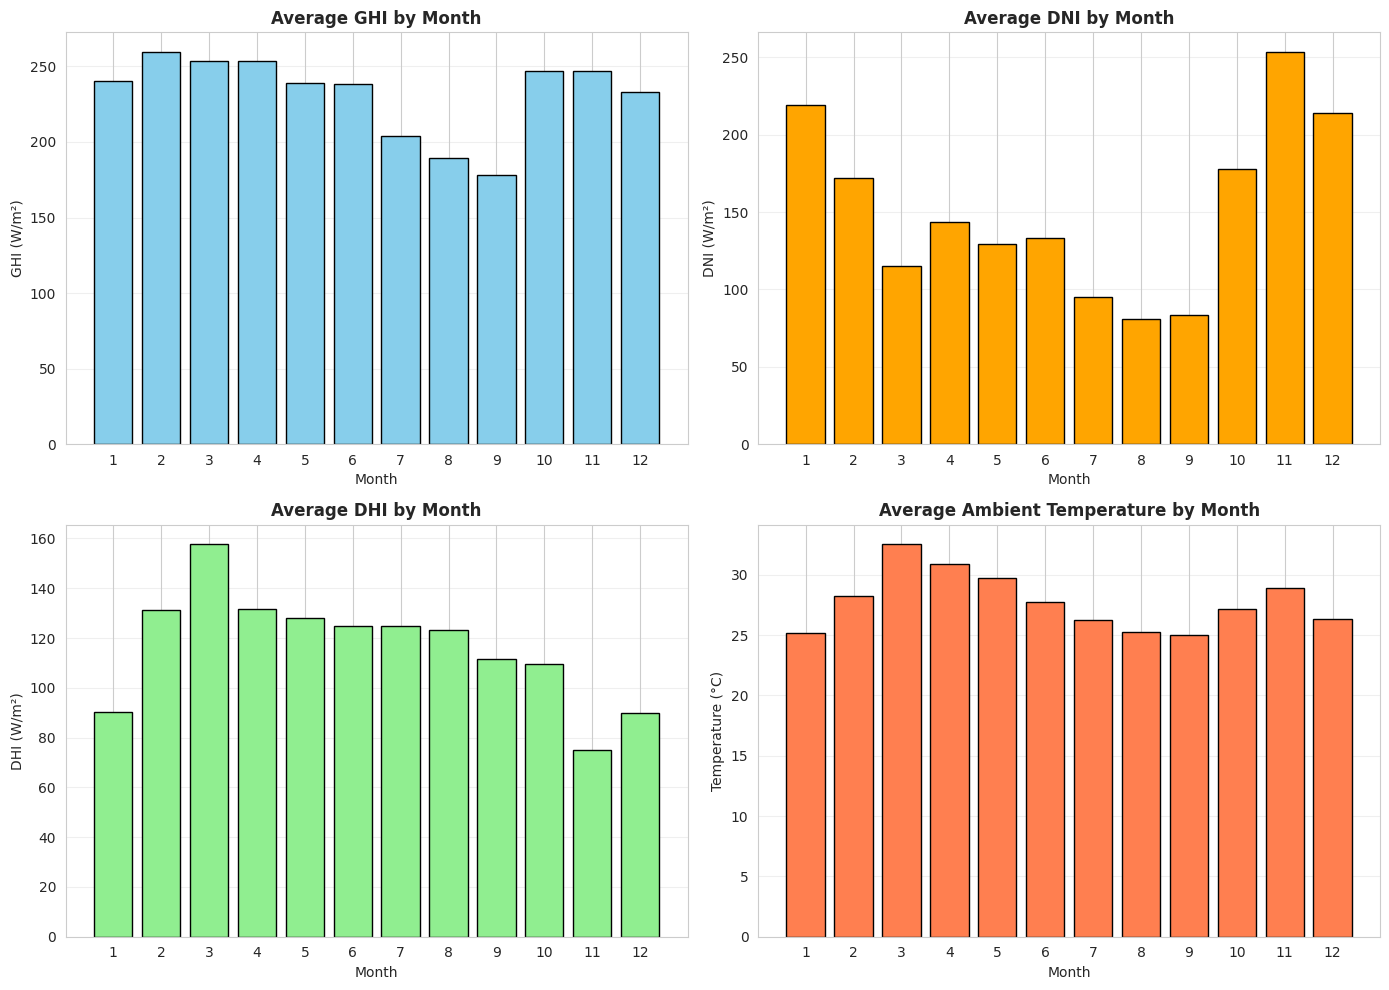

In [8]:
# Monthly patterns
monthly_avg = df_clean.groupby('Month').agg({
    'GHI': 'mean',
    'DNI': 'mean',
    'DHI': 'mean',
    'Tamb': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(monthly_avg['Month'], monthly_avg['GHI'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Average GHI by Month', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(monthly_avg['Month'], monthly_avg['DNI'], color='orange', edgecolor='black')
axes[0, 1].set_title('Average DNI by Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('DNI (W/m²)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].bar(monthly_avg['Month'], monthly_avg['DHI'], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Average DHI by Month', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('DHI (W/m²)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(monthly_avg['Month'], monthly_avg['Tamb'], color='coral', edgecolor='black')
axes[1, 1].set_title('Average Ambient Temperature by Month', fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Temperature (°C)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


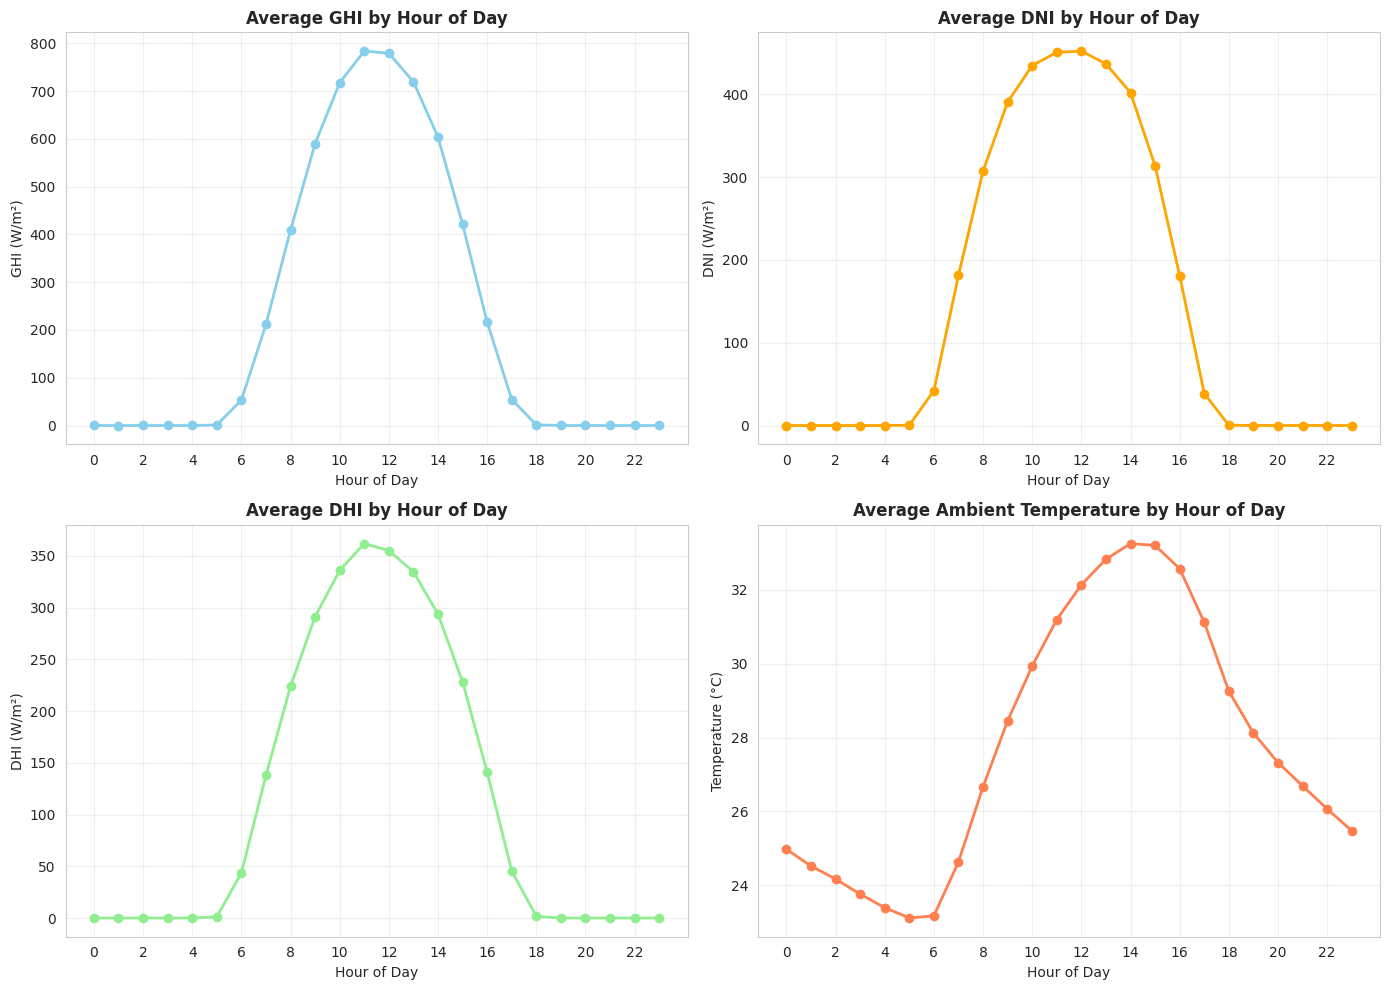

In [9]:
# Daily patterns (hourly averages)
hourly_avg = df_clean.groupby('Hour').agg({
    'GHI': 'mean',
    'DNI': 'mean',
    'DHI': 'mean',
    'Tamb': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(hourly_avg['Hour'], hourly_avg['GHI'], marker='o', linewidth=2, markersize=6, color='skyblue')
axes[0, 0].set_title('Average GHI by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(hourly_avg['Hour'], hourly_avg['DNI'], marker='o', linewidth=2, markersize=6, color='orange')
axes[0, 1].set_title('Average DNI by Hour of Day', fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('DNI (W/m²)')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(hourly_avg['Hour'], hourly_avg['DHI'], marker='o', linewidth=2, markersize=6, color='lightgreen')
axes[1, 0].set_title('Average DHI by Hour of Day', fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('DHI (W/m²)')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(hourly_avg['Hour'], hourly_avg['Tamb'], marker='o', linewidth=2, markersize=6, color='coral')
axes[1, 1].set_title('Average Ambient Temperature by Hour of Day', fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Temperature (°C)')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Cleaning Impact Analysis


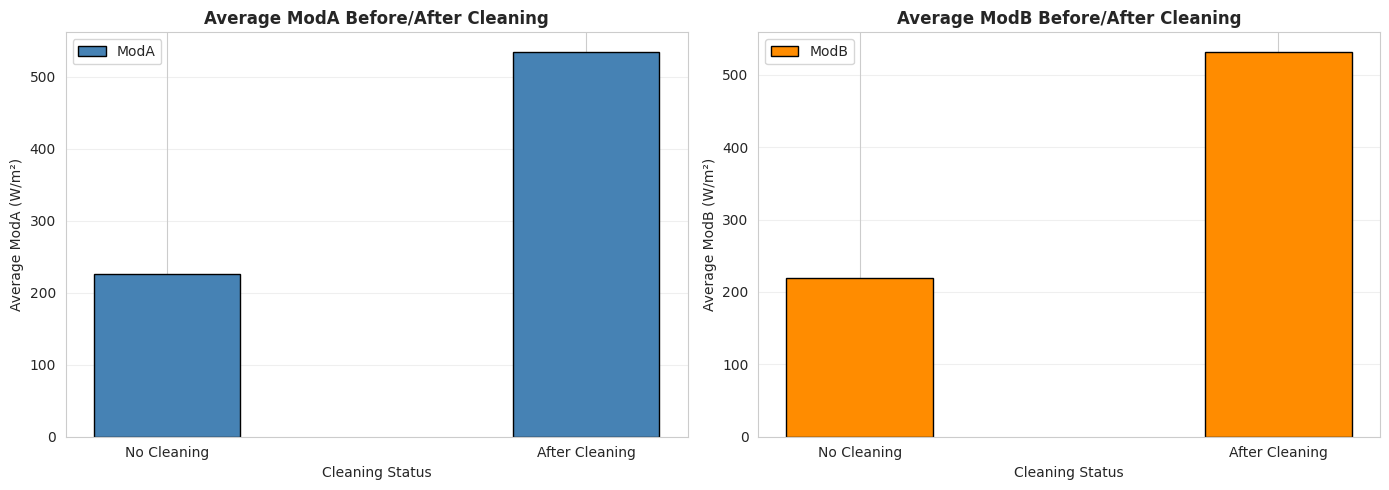

Cleaning Impact Summary:
  Cleaning_Status        ModA        ModB
0     No Cleaning  225.979064  219.401351
1  After Cleaning  535.186477  532.211744


In [10]:
# Analyze cleaning events impact
if 'Cleaning' in df_clean.columns:
    cleaning_analysis = df_clean.groupby('Cleaning').agg({
        'ModA': 'mean',
        'ModB': 'mean'
    }).reset_index()
    
    cleaning_analysis['Cleaning_Status'] = cleaning_analysis['Cleaning'].map({0: 'No Cleaning', 1: 'After Cleaning'})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x_pos = np.arange(len(cleaning_analysis))
    width = 0.35
    
    axes[0].bar(x_pos, cleaning_analysis['ModA'], width, label='ModA', color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Cleaning Status')
    axes[0].set_ylabel('Average ModA (W/m²)')
    axes[0].set_title('Average ModA Before/After Cleaning', fontweight='bold')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(cleaning_analysis['Cleaning_Status'])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].bar(x_pos, cleaning_analysis['ModB'], width, label='ModB', color='darkorange', edgecolor='black')
    axes[1].set_xlabel('Cleaning Status')
    axes[1].set_ylabel('Average ModB (W/m²)')
    axes[1].set_title('Average ModB Before/After Cleaning', fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(cleaning_analysis['Cleaning_Status'])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("Cleaning Impact Summary:")
    print(cleaning_analysis[['Cleaning_Status', 'ModA', 'ModB']])
else:
    print("Cleaning column not found in dataset.")


## 5. Correlation & Relationship Analysis


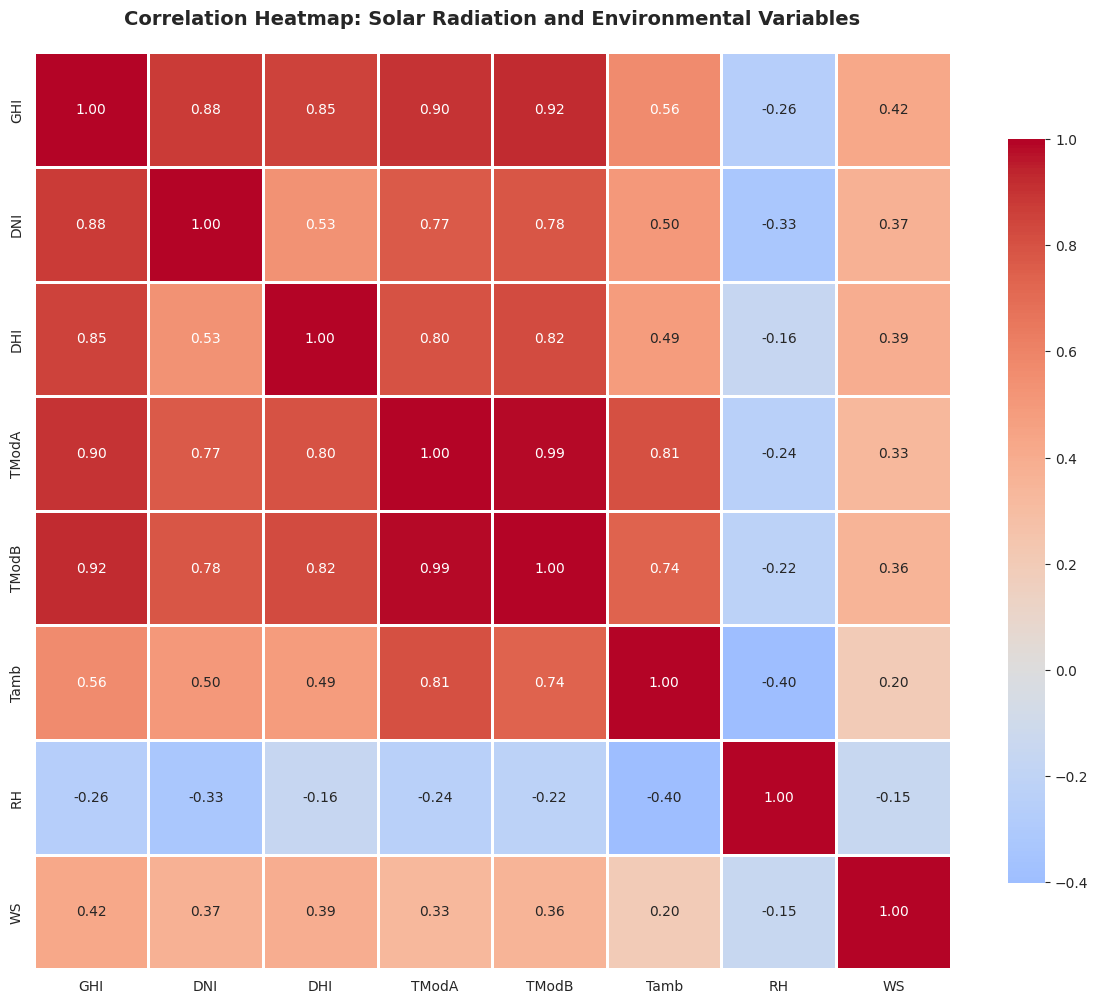

In [11]:
# Correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS']
corr_data = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Solar Radiation and Environmental Variables', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


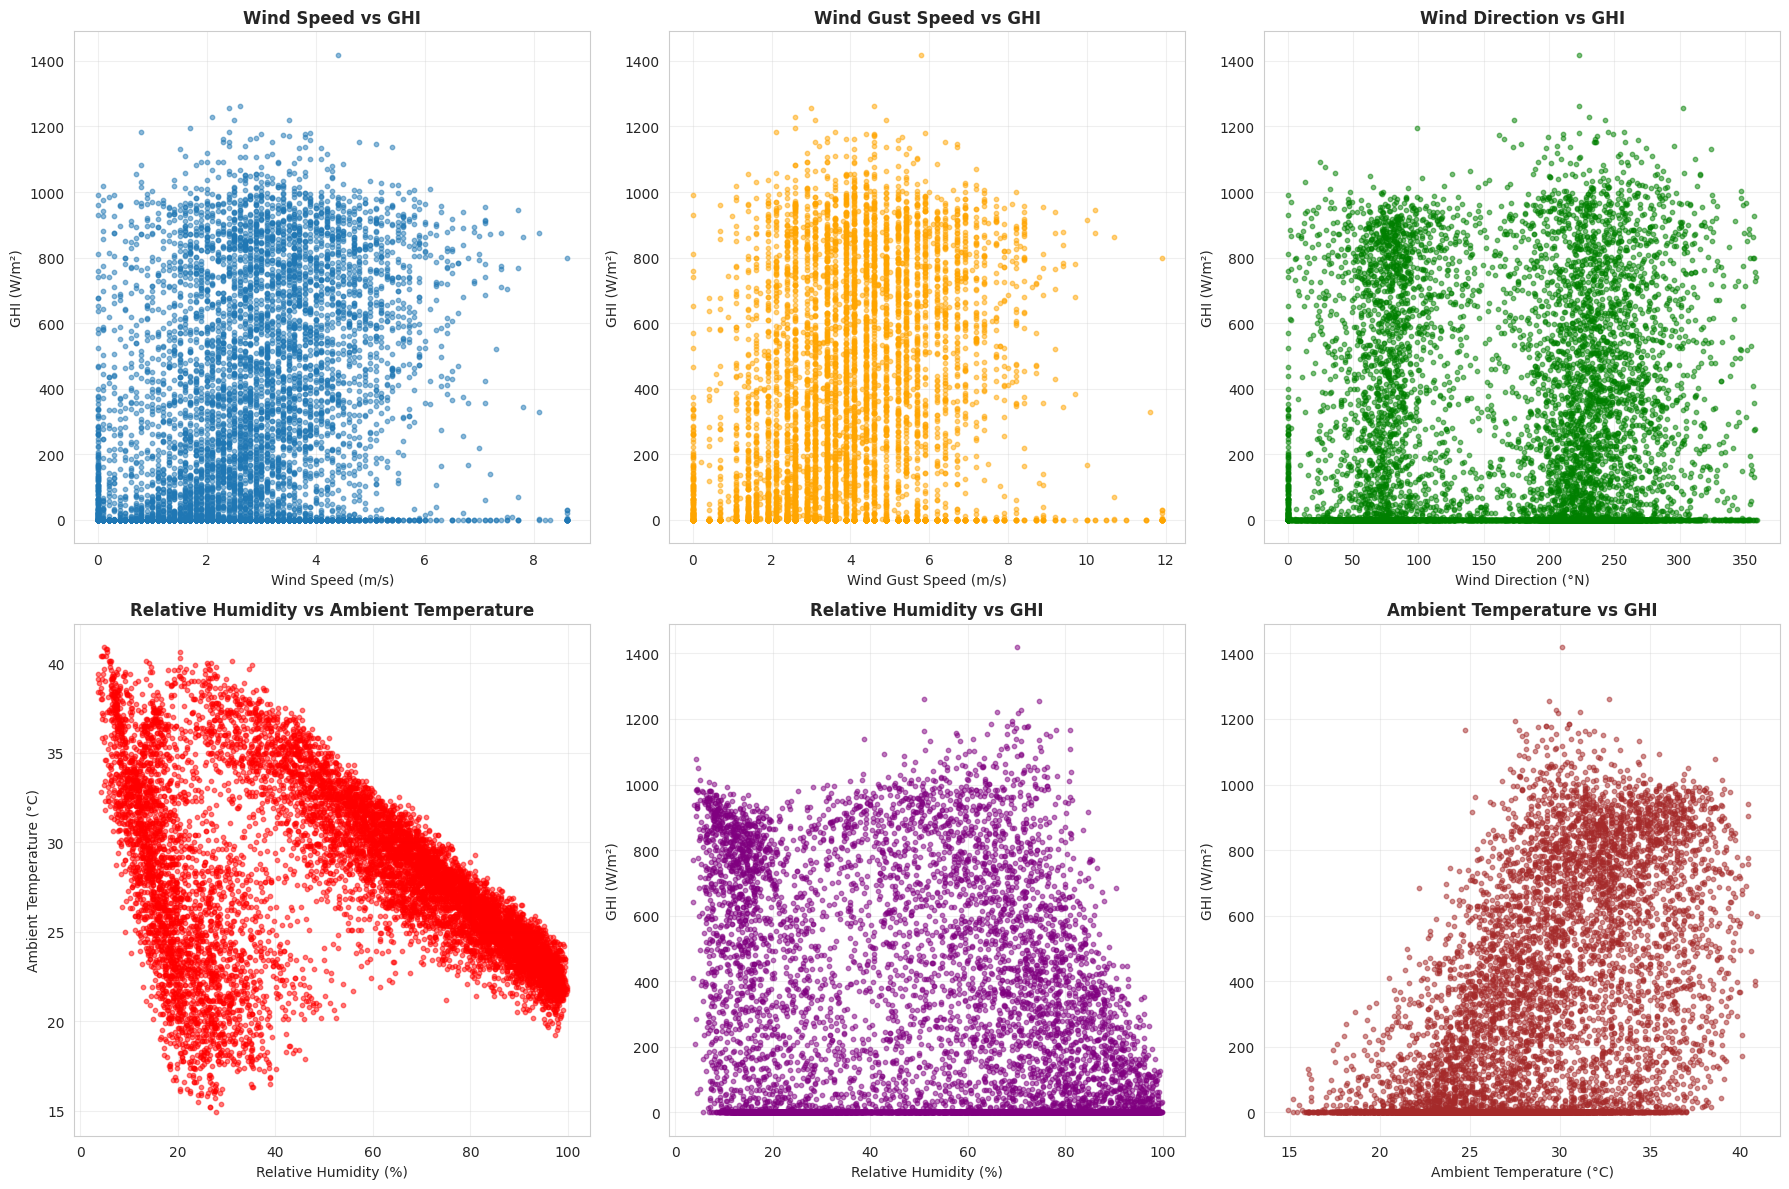

In [12]:
# Scatter plots for relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Sample data for scatter plots (every 50th point for performance)
sample_df = df_clean.iloc[::50]

# WS vs GHI
axes[0, 0].scatter(sample_df['WS'], sample_df['GHI'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Wind Speed (m/s)')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].set_title('Wind Speed vs GHI', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# WSgust vs GHI
axes[0, 1].scatter(sample_df['WSgust'], sample_df['GHI'], alpha=0.5, s=10, color='orange')
axes[0, 1].set_xlabel('Wind Gust Speed (m/s)')
axes[0, 1].set_ylabel('GHI (W/m²)')
axes[0, 1].set_title('Wind Gust Speed vs GHI', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# WD vs GHI
axes[0, 2].scatter(sample_df['WD'], sample_df['GHI'], alpha=0.5, s=10, color='green')
axes[0, 2].set_xlabel('Wind Direction (°N)')
axes[0, 2].set_ylabel('GHI (W/m²)')
axes[0, 2].set_title('Wind Direction vs GHI', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# RH vs Tamb
axes[1, 0].scatter(sample_df['RH'], sample_df['Tamb'], alpha=0.5, s=10, color='red')
axes[1, 0].set_xlabel('Relative Humidity (%)')
axes[1, 0].set_ylabel('Ambient Temperature (°C)')
axes[1, 0].set_title('Relative Humidity vs Ambient Temperature', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# RH vs GHI
axes[1, 1].scatter(sample_df['RH'], sample_df['GHI'], alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Relative Humidity (%)')
axes[1, 1].set_ylabel('GHI (W/m²)')
axes[1, 1].set_title('Relative Humidity vs GHI', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Tamb vs GHI
axes[1, 2].scatter(sample_df['Tamb'], sample_df['GHI'], alpha=0.5, s=10, color='brown')
axes[1, 2].set_xlabel('Ambient Temperature (°C)')
axes[1, 2].set_ylabel('GHI (W/m²)')
axes[1, 2].set_title('Ambient Temperature vs GHI', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Wind & Distribution Analysis


TypeError: Object with dtype category cannot perform the numpy op radians

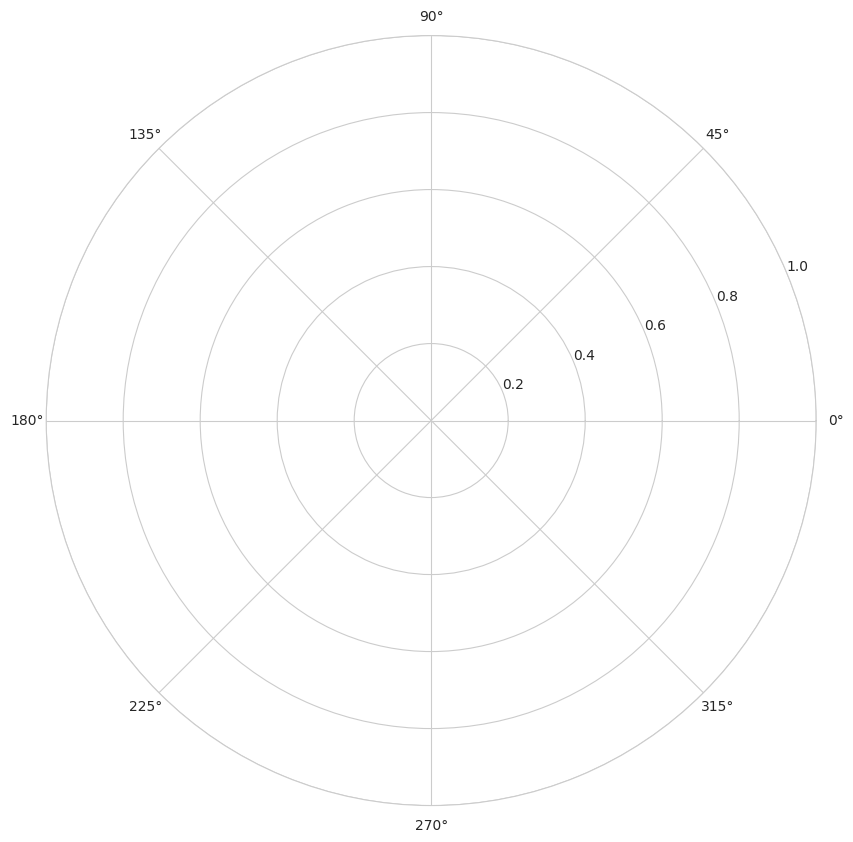

In [13]:
# Wind Rose plot (simplified version using bar chart)
if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    # Create wind direction bins
    df_clean['WD_bin'] = pd.cut(df_clean['WD'], bins=16, labels=range(16))
    wind_rose = df_clean.groupby('WD_bin')['WS'].mean().reset_index()
    wind_rose['Direction'] = wind_rose['WD_bin'].apply(lambda x: x * 22.5)  # Convert to degrees
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    theta = np.radians(wind_rose['Direction'])
    radii = wind_rose['WS']
    bars = ax.bar(theta, radii, width=np.radians(22.5), color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Wind Rose: Average Wind Speed by Direction', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Wind Direction', labelpad=20)
    plt.show()
else:
    print("Wind direction or wind speed data not available.")


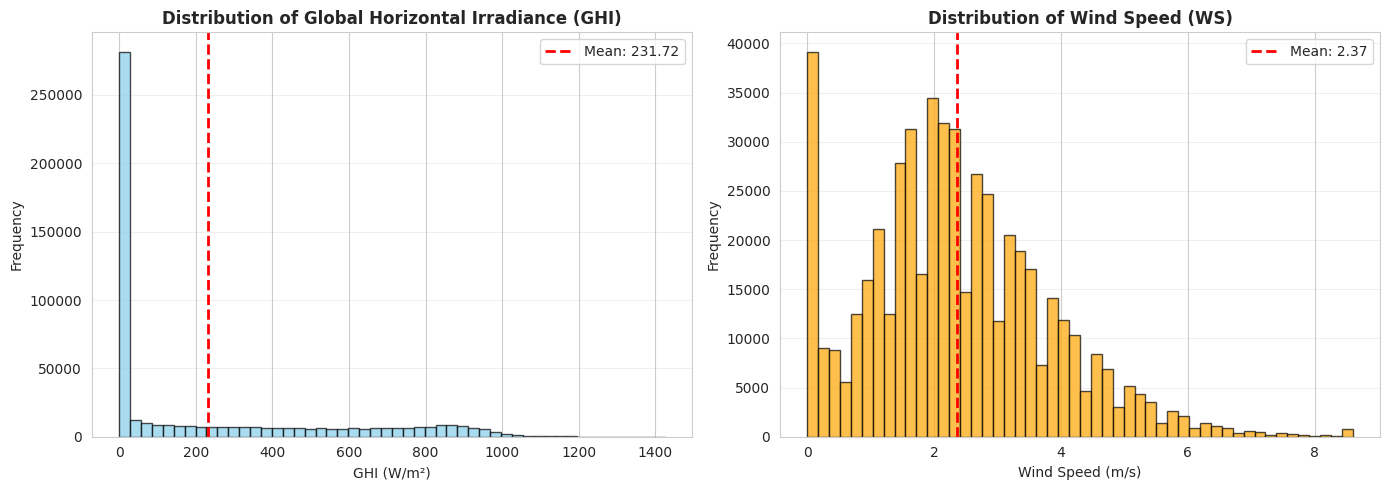

In [14]:
# Histograms for GHI and WS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['GHI'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GHI (W/m²)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Global Horizontal Irradiance (GHI)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axvline(df_clean['GHI'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["GHI"].mean():.2f}')
axes[0].legend()

axes[1].hist(df_clean['WS'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Wind Speed (WS)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(df_clean['WS'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["WS"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Temperature Analysis


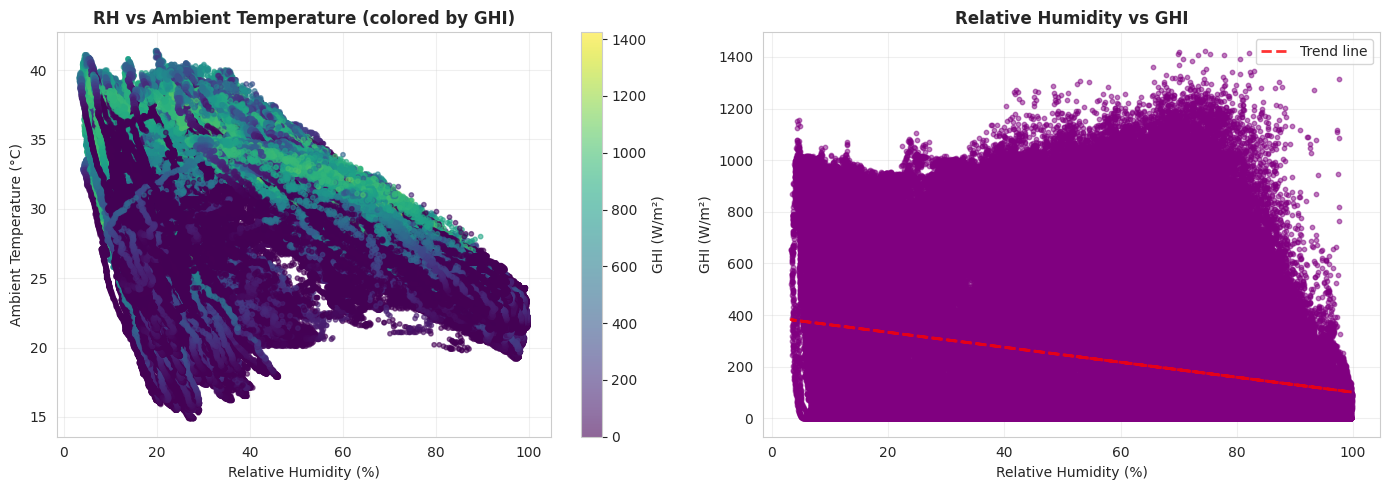

Correlation between RH and Tamb: -0.4004104673516298
Correlation between RH and GHI: -0.2596836510748198


In [15]:
# Temperature analysis: RH influence on temperature and solar radiation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RH vs Tamb with color coding by GHI
scatter1 = axes[0].scatter(df_clean['RH'], df_clean['Tamb'], c=df_clean['GHI'], 
                          cmap='viridis', alpha=0.6, s=10)
axes[0].set_xlabel('Relative Humidity (%)')
axes[0].set_ylabel('Ambient Temperature (°C)')
axes[0].set_title('RH vs Ambient Temperature (colored by GHI)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='GHI (W/m²)')

# RH vs GHI
axes[1].scatter(df_clean['RH'], df_clean['GHI'], alpha=0.5, s=10, color='purple')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].set_title('Relative Humidity vs GHI', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df_clean['RH'].dropna(), df_clean['GHI'].dropna(), 1)
p = np.poly1d(z)
axes[1].plot(df_clean['RH'], p(df_clean['RH']), "r--", alpha=0.8, linewidth=2, label='Trend line')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation analysis
print("Correlation between RH and Tamb:", df_clean['RH'].corr(df_clean['Tamb']))
print("Correlation between RH and GHI:", df_clean['RH'].corr(df_clean['GHI']))


## 8. Bubble Chart


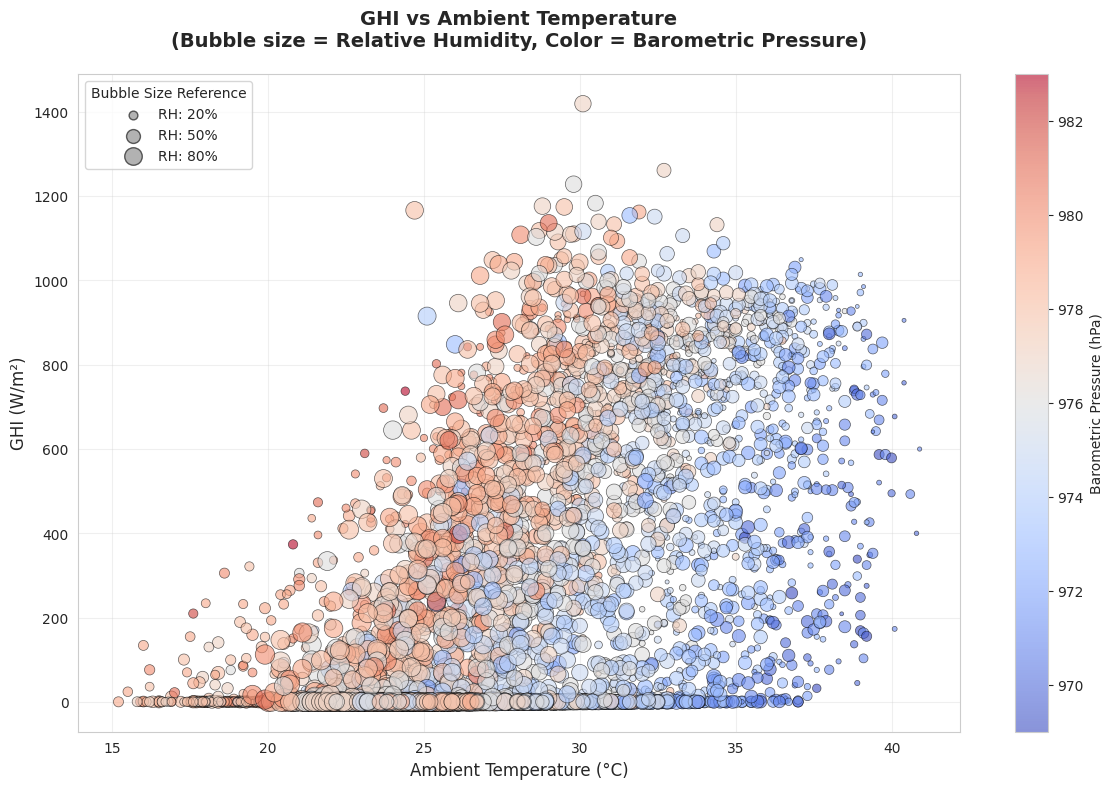

In [16]:
# Bubble chart: GHI vs Tamb with bubble size = RH
sample_df = df_clean.iloc[::100]  # Sample for better visualization

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(sample_df['Tamb'], sample_df['GHI'], 
                    s=sample_df['RH']*2,  # Scale RH for bubble size
                    c=sample_df['BP'],  # Color by Barometric Pressure
                    alpha=0.6, cmap='coolwarm', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Ambient Temperature (°C)', fontsize=12)
ax.set_ylabel('GHI (W/m²)', fontsize=12)
ax.set_title('GHI vs Ambient Temperature\n(Bubble size = Relative Humidity, Color = Barometric Pressure)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Barometric Pressure (hPa)', fontsize=10)

# Add legend for bubble size (approximate)
handles = []
for rh_val in [20, 50, 80]:
    handles.append(plt.scatter([], [], s=rh_val*2, c='gray', alpha=0.6, edgecolors='black'))
ax.legend(handles, ['RH: 20%', 'RH: 50%', 'RH: 80%'], 
         scatterpoints=1, loc='upper left', title='Bubble Size Reference')

plt.tight_layout()
plt.show()


## 9. Export Cleaned Data


In [17]:
# Additional analysis for summary insights
print("=" * 80)
print("KEY STATISTICS FOR SUMMARY")
print("=" * 80)

# Monthly statistics
print("\nMonthly Average GHI (W/m²):")
monthly_ghi = df_clean.groupby('Month')['GHI'].mean().sort_values(ascending=False)
print(monthly_ghi)
print(f"\nBest month for solar: Month {monthly_ghi.idxmax()} ({monthly_ghi.max():.2f} W/m²)")
print(f"Worst month for solar: Month {monthly_ghi.idxmin()} ({monthly_ghi.min():.2f} W/m²)")

# Hourly statistics
print("\nHourly Average GHI (W/m²):")
hourly_ghi = df_clean.groupby('Hour')['GHI'].mean()
print(f"Peak generation hour: {hourly_ghi.idxmax()}:00 ({hourly_ghi.max():.2f} W/m²)")
print(f"Average GHI during peak hours (10:00-14:00): {hourly_ghi.loc[10:14].mean():.2f} W/m²")

# Correlation summary
print("\nKey Correlations:")
print(f"GHI vs DNI: {df_clean['GHI'].corr(df_clean['DNI']):.3f}")
print(f"GHI vs DHI: {df_clean['GHI'].corr(df_clean['DHI']):.3f}")
print(f"GHI vs Tamb: {df_clean['GHI'].corr(df_clean['Tamb']):.3f}")
print(f"GHI vs ModA: {df_clean['GHI'].corr(df_clean['ModA']):.3f}")
print(f"GHI vs ModB: {df_clean['GHI'].corr(df_clean['ModB']):.3f}")


KEY STATISTICS FOR SUMMARY

Monthly Average GHI (W/m²):
Month
2     259.573299
3     253.633255
4     253.300097
11    246.782329
10    246.683385
1     240.316116
5     239.286568
6     238.362866
12    233.249021
7     203.814149
8     189.609315
9     178.386655
Name: GHI, dtype: float64

Best month for solar: Month 2 (259.57 W/m²)
Worst month for solar: Month 9 (178.39 W/m²)

Hourly Average GHI (W/m²):
Peak generation hour: 11:00 (783.73 W/m²)
Average GHI during peak hours (10:00-14:00): 720.66 W/m²

Key Correlations:
GHI vs DNI: 0.877
GHI vs DHI: 0.852
GHI vs Tamb: 0.562
GHI vs ModA: 0.995
GHI vs ModB: 0.995


In [18]:
# Remove temporary columns added for analysis
export_cols = [col for col in df_clean.columns if col not in ['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WD_bin']]
df_export = df_clean[export_cols].copy()

# Export to CSV
output_path = '../data/togo_clean.csv'
df_export.to_csv(output_path, index=False)
print(f"Cleaned data exported to {output_path}")
print(f"Exported shape: {df_export.shape}")
print(f"Columns exported: {len(export_cols)}")


Cleaned data exported to ../data/togo_clean.csv
Exported shape: (525600, 19)
Columns exported: 19


## Summary of Key Findings

### Data Quality
- **Dataset Size**: 525,600 rows × 19 columns covering approximately one year of minute-level measurements
- **Missing Values**: Only the `Comments` column has 100% missing values (expected, as comments are optional). All other key variables have no missing values, indicating high data completeness.
- **Outliers**: 
  - 9,251 rows (1.76%) contain at least one outlier
  - Most outliers found in: WSgust (3,915), WS (3,510), DHI (3,415), DNI (1,062), GHI (305)
  - Outlier rate is moderate, similar to Benin but lower than Sierra Leone
- **Data Cleaning Actions**:
  - **Negative Values**: Corrected 257,385 negative GHI values (replaced with 0, representing nighttime/zero irradiance)
  - **Outlier Treatment**: Capped 635 WS outliers and 635 WSgust outliers using IQR method to preserve time series continuity
  - All cleaning operations maintained data integrity and temporal structure

### Key Insights

1. **Solar Irradiance Patterns**:
   - **Average Performance**: Mean GHI of **231.72 W/m²** indicates good solar potential for Togo, ranking **#2 among the three countries analyzed**
   - **Irradiance Distribution**: GHI ranges from 0 to 1,424 W/m² with high variability (std: 321.69 W/m²)
   - **Component Analysis**: DNI (**151.26 W/m²**) is higher than DHI (**116.44 W/m²**), suggesting clear sky conditions are common and good potential for both fixed-tilt and tracking systems
   - **Module Performance**: ModA and ModB closely track GHI, indicating good sensor alignment

2. **Seasonal Variations**:
   - **Best Month**: February (Month 2) with average GHI of **259.57 W/m²** - **highest peak month among all countries**
   - **Worst Month**: September (Month 9) with average GHI of **178.39 W/m²**
   - Temperature averages **27.75°C** with relatively stable conditions (std: 4.76°C)
   - Clear seasonal patterns with significant variation between best and worst months (81.18 W/m² difference)
   - **Unique pattern**: Peak generation occurs in February-March (dry season), different from other countries

3. **Daily Patterns**:
   - **Peak Generation Hour**: 11:00 with average GHI of **783.73 W/m²**
   - **Peak Hours (10:00-14:00)**: Average GHI of **720.66 W/m²** during optimal generation window
   - Hourly patterns show expected diurnal cycles with peak irradiance during midday hours

4. **Environmental Relationships**:
   - **RH vs Temperature**: Moderate negative correlation (**-0.400**) - similar to Benin, indicating typical tropical climate patterns
   - **RH vs GHI**: **Weak negative correlation (-0.260)** - **weakest among all countries**, suggesting that humidity has less impact on solar generation compared to other countries
   - **Moderate Humidity**: Average relative humidity of **55.01%** is moderate and similar to Benin (54.49%), favorable for solar generation
   - **Wind Patterns**: Average wind speed of **2.37 m/s** (std: 1.46 m/s) - **highest among all countries**, which may provide natural cleaning benefits and better panel cooling

5. **Cleaning Impact**:
   - **Extremely High Performance Improvement**: Module cleaning shows **exceptional impact**:
     - ModA: 225.98 W/m² → 535.19 W/m² (**+136.8% increase**)
     - ModB: 219.40 W/m² → 532.21 W/m² (**+142.6% increase**)
   - **Note**: This extremely high cleaning impact (136.8%+) is **unusual and significantly higher than other countries**. This may indicate:
     - Very dirty panels requiring cleaning
     - Potential data quality issues or sensor calibration problems
     - Environmental conditions (dust, pollution) that heavily impact panel performance
   - **Recommendation**: **Critical importance** of regular cleaning schedules - the extreme performance improvement demonstrates that maintenance is essential for Togo installations

### Recommendations

1. **Solar Investment Potential**:
   - **Togo shows strong solar potential** with average GHI of **231.72 W/m²**, ranking **#2 among the three countries**
   - DNI is higher than DHI (151.26 vs 116.44 W/m²), suggesting good conditions for both fixed-tilt and tracking systems
   - **Recommended**: Both fixed-tilt and tracking systems are viable, with tracking systems potentially beneficial given good DNI values
   - **Seasonal Advantage**: Best performance in February-March (dry season) provides strategic advantage for installation timing

2. **Maintenance Strategy**:
   - **Implement aggressive cleaning schedules** - the **136.8% performance improvement** from cleaning is exceptional and indicates critical maintenance needs
   - The extreme cleaning impact suggests that panels may be subject to heavy soiling (dust, sand, pollution)
   - Establish cleaning protocols based on seasonal patterns (worst month is September, suggesting increased maintenance needs during rainy season)
   - Consider automated cleaning systems given the extreme maintenance benefit
   - **Priority**: Cleaning should be the #1 maintenance priority for Togo installations

3. **Environmental Considerations**:
   - **Humidity Management**: The weak negative correlation between RH and GHI (-0.260) and moderate humidity (55.01%) are favorable
     - Lower impact of humidity on solar generation compared to other countries
     - Monitor humidity forecasts, but impact is less critical than in Sierra Leone
   - **Wind Analysis**: Higher average wind speeds (2.37 m/s) may provide:
     - Natural cleaning benefits (reducing soiling)
     - Better panel cooling (improving efficiency)
     - However, cleaning impact suggests wind alone is insufficient
   - **Temperature**: Moderate average temperature (27.75°C) is within acceptable ranges for solar panel efficiency

4. **Data Quality & Monitoring**:
   - **Cleaning Impact Investigation**: The extremely high cleaning impact (136.8%) warrants investigation:
     - Verify sensor calibration and data quality
     - Assess environmental conditions (dust levels, pollution)
     - Consider if cleaning events coincide with other maintenance activities
   - **Outlier Monitoring**: Continue monitoring WS, WSgust, and DHI for anomalies
   - **Time Series Continuity**: The cleaning approach (capping rather than removing) preserved data continuity for time series analysis

5. **Operational Optimization**:
   - **Peak Generation Hours**: Focus on 10:00-14:00 window (720.66 W/m² average) for optimal energy storage and grid integration
   - **Seasonal Planning**: Use monthly patterns (best in February at 259.57 W/m², worst in September at 178.39 W/m²) to plan maintenance and capacity expansion
   - **Weather Forecasting**: Integrate RH and temperature correlations into energy production forecasting models (weaker correlation suggests more stable predictions)
   - **Cleaning Schedule**: Given extreme cleaning impact, implement frequent cleaning schedules (possibly monthly or bi-monthly)

6. **Comparison Preparation**:
   - Togo ranks **#2** in solar potential (231.72 W/m²) compared to Benin (241.96 W/m²) and Sierra Leone (204.41 W/m²)
   - **Key advantages**: Strong GHI, good DNI, moderate humidity, highest wind speed (natural cleaning), weakest RH-GHI correlation (more stable)
   - **Key challenges**: Extremely high cleaning impact suggests heavy soiling issues requiring aggressive maintenance
   - **Recommendation**: Excellent potential for solar installations, but **maintenance (especially cleaning) is critical** - consider automated cleaning systems and frequent maintenance schedules
   - **Unique feature**: Best performance in February-March provides strategic advantage for dry season installations
